# Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1.Cargar datos

# Carga de la bbdd Banco

In [2]:
#cargar datos
df = pd.read_parquet("../../data/df_limpiado_260504.parquet")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,contactado_campania_previa
0,59,administration,married,secondary,no,2343,yes,no,unknown,5,may,1042.0,1,NaN,0,sin_campania_previa,yes,0
1,56,administration,married,secondary,no,45,no,no,unknown,5,may,1467.0,1,NaN,0,sin_campania_previa,yes,0
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389.0,1,NaN,0,sin_campania_previa,yes,0
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579.0,1,NaN,0,sin_campania_previa,yes,0
4,54,administration,married,tertiary,no,184,no,no,unknown,5,may,673.0,2,NaN,0,sin_campania_previa,yes,0


In [3]:
#Nos quedamos con las variables que usaremos para perfil de cliente
cols = ["age", "job", "marital", "education", "balance", "default", "housing", "loan", "deposit"]

df_perfil = df[cols].copy()
df_perfil.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  string
 2   marital    11162 non-null  string
 3   education  11162 non-null  string
 4   balance    11162 non-null  int64 
 5   default    11162 non-null  string
 6   housing    11162 non-null  string
 7   loan       11162 non-null  string
 8   deposit    11162 non-null  string
dtypes: int64(2), string(7)
memory usage: 1.1 MB


In [4]:
df_perfil["age_group"] = pd.cut(df_perfil["age"], bins=[0, 25, 35, 45, 55, 65, 120], labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"])

#Eliminamos la columna numérica original
df_perfil = df_perfil.drop(columns=["age"])

In [5]:
dist_edad_banco = df_perfil.groupby("age_group").size()
dist_edad_banco

age_group
<=25      449
26-35    3920
36-45    3162
46-55    2147
56-65    1086
65+       398
dtype: int64

# Carga de csv proyecciones poblacionales

In [6]:
proyeccion = pd.read_csv("../../data/df_original_proyeccion_260511.csv")
pd.options.display.float_format = '{:,.2f}'.format
proyeccion.info()

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Periodo           11 non-null     int64  
 1   <=25              11 non-null     float64
 2   26-35             11 non-null     float64
 3   36-45             11 non-null     float64
 4   46-55             11 non-null     float64
 5   56-65             11 non-null     float64
 6   65+               11 non-null     float64
 7   Total_pobl        11 non-null     float64
 8   Crecimiento_pobl  11 non-null     str    
 9   Edad_media        11 non-null     str    
 10  Ind_envejecer     11 non-null     str    
 11  Saldo_vegetativo  11 non-null     str    
 12  Saldo_migratorio  11 non-null     str    
 13  Tasa_mortalidad   11 non-null     str    
 14  Tasa_natalidad    11 non-null     str    
dtypes: float64(7), int64(1), str(7)
memory usage: 2.1 KB


In [7]:
# Identificar columnas que son string
cols_str = proyeccion.select_dtypes(include="object").columns

# Reemplazar comas y convertir a float en todas ellas
for col in cols_str:
    proyeccion[col] = (
        proyeccion[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

proyeccion.dtypes

C:\Users\misab\AppData\Local\Temp\ipykernel_10408\1066721387.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_str = proyeccion.select_dtypes(include="object").columns


Periodo               int64
<=25                float64
26-35               float64
36-45               float64
46-55               float64
56-65               float64
65+                 float64
Total_pobl          float64
Crecimiento_pobl    float64
Edad_media          float64
Ind_envejecer       float64
Saldo_vegetativo    float64
Saldo_migratorio    float64
Tasa_mortalidad     float64
Tasa_natalidad      float64
dtype: object

## 2.Visualizaciones

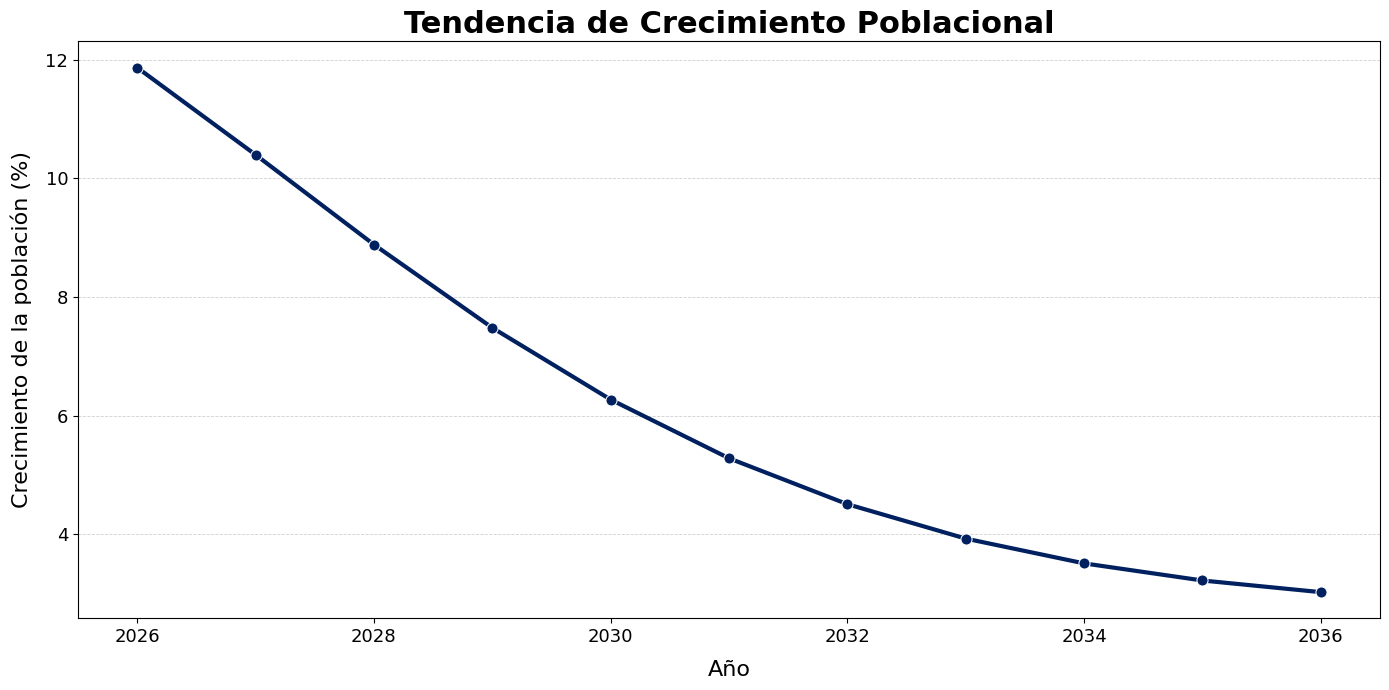

In [8]:
#grafico tendencia crecimiento

plt.figure(figsize=(14, 7))

# Color corporativo:
#color=["#002060", "#2BA86E"]

sns.lineplot(
    data=proyeccion,
    x="Periodo",
    y="Crecimiento_pobl",
    color="#002060",
    linewidth=3,
    marker="o",
    markersize=8
)

plt.title(
    "Tendencia de Crecimiento Poblacional",
    fontsize=22,
    fontweight="bold",
)

plt.xlabel("Año", fontsize=16, labelpad=10)
plt.ylabel("Crecimiento de la población (%)", fontsize=16, labelpad=10)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

plt.tight_layout()
plt.show()

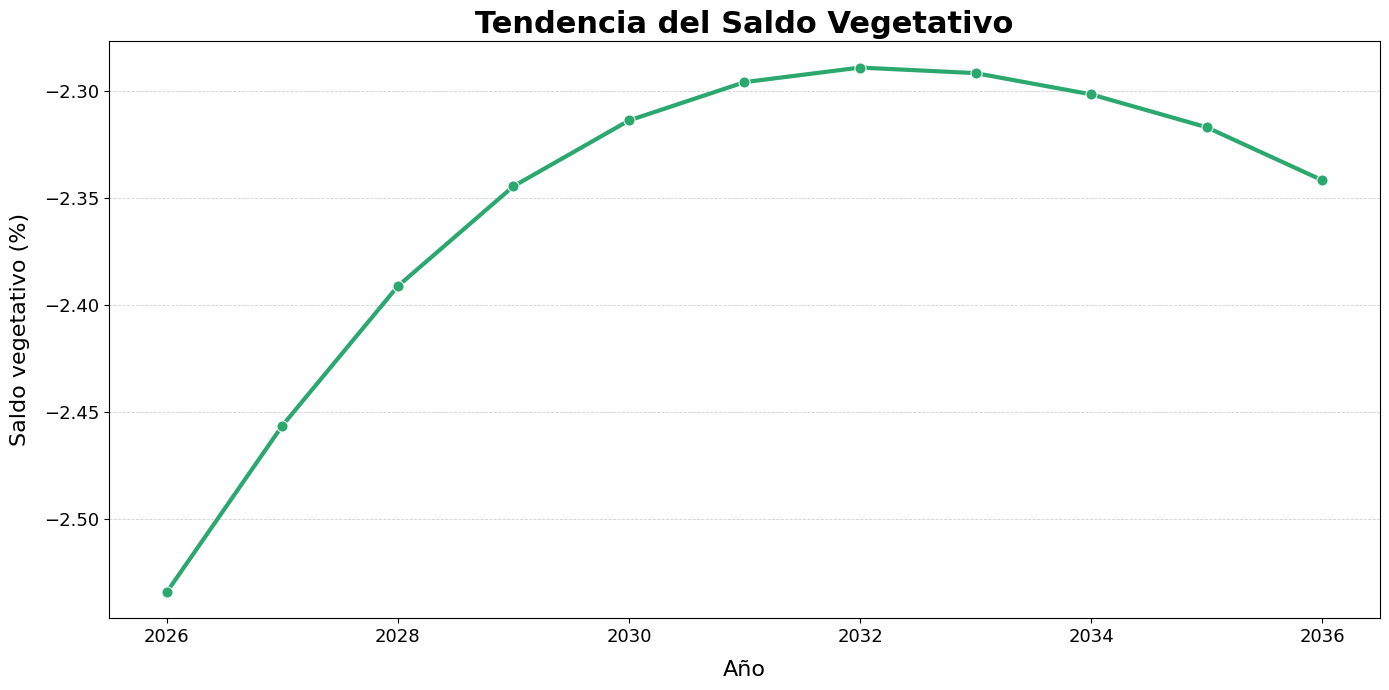

In [9]:
#grafico saldo vegetativo

plt.figure(figsize=(14, 7))

# Color corporativo:
#color=["#002060", "#2BA86E"]

sns.lineplot(
    data=proyeccion,
    x="Periodo",
    y="Saldo_vegetativo",
    color="#2BA86E",
    linewidth=3,
    marker="o",
    markersize=8
)

plt.title(
    "Tendencia del Saldo Vegetativo",
    fontsize=22,
    fontweight="bold",
)

plt.xlabel("Año", fontsize=16, labelpad=10)
plt.ylabel("Saldo vegetativo (%)", fontsize=16, labelpad=10)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

plt.tight_layout()
plt.show()

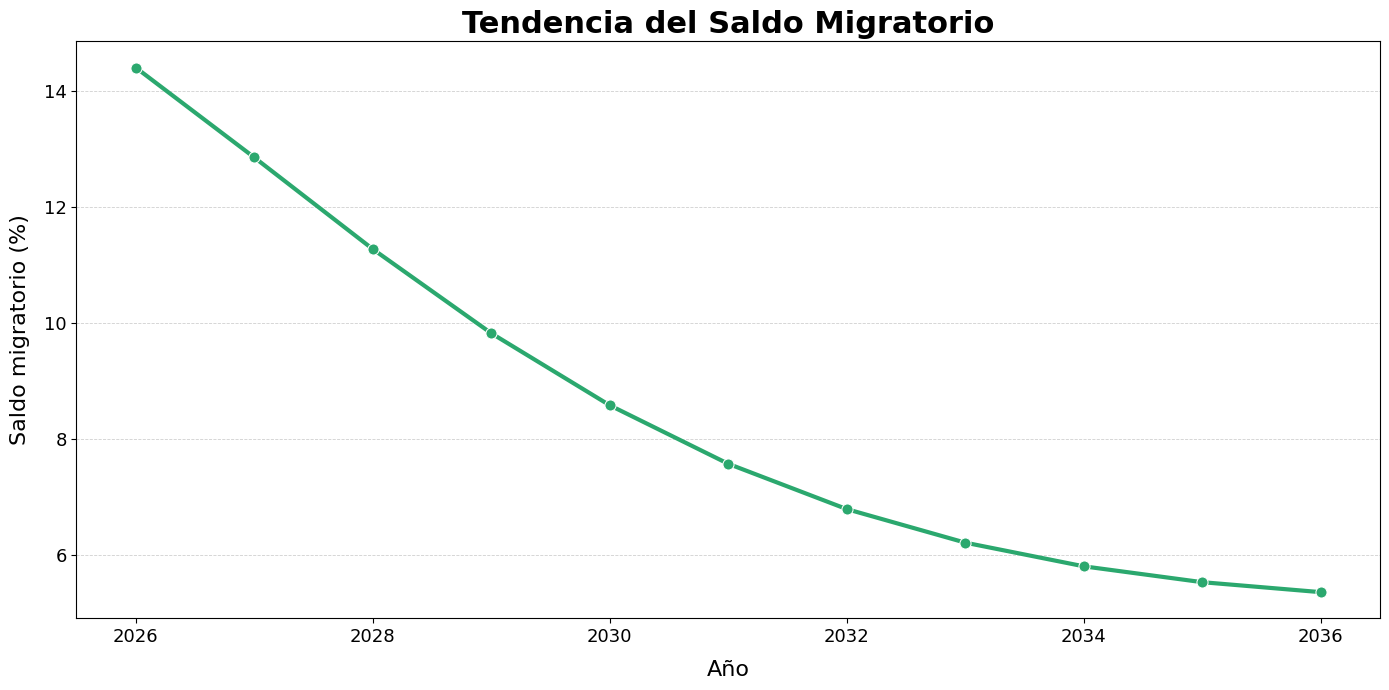

In [10]:
#grafico saldo migratorio

plt.figure(figsize=(14, 7))

# Color corporativo:
#color=["#002060", "#2BA86E"]

sns.lineplot(
    data=proyeccion,
    x="Periodo",
    y="Saldo_migratorio",
    color="#2BA86E",
    linewidth=3,
    marker="o",
    markersize=8
)

plt.title(
    "Tendencia del Saldo Migratorio",
    fontsize=22,
    fontweight="bold",
)

plt.xlabel("Año", fontsize=16, labelpad=10)
plt.ylabel("Saldo migratorio (%)", fontsize=16, labelpad=10)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

plt.tight_layout()
plt.show()

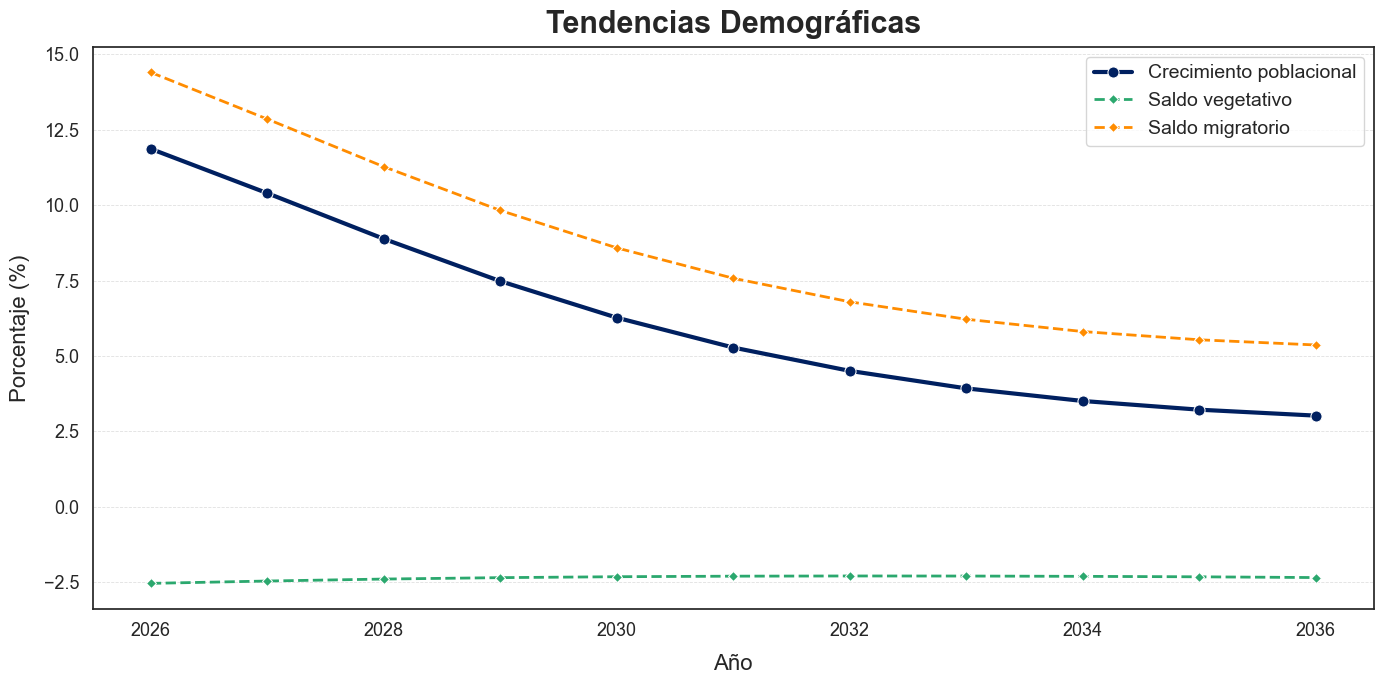

In [24]:
#Grafico tres tendencias en una
plt.figure(figsize=(14, 7))

# Línea 1: Crecimiento poblacional
sns.lineplot(
    data=proyeccion,
    x="Periodo",
    y="Crecimiento_pobl",
    color="#002060",
    linewidth=3,
    marker="o",
    markersize=8,
    label="Crecimiento poblacional"
)

# Línea 2: Saldo vegetativo
sns.lineplot(
    data=proyeccion,
    x="Periodo",
    y="Saldo_vegetativo",
    color="#2BA86E",
    linewidth=2,
    linestyle="--",
    marker="D",
    markersize=5,
    label="Saldo vegetativo"
)

# Línea 3: Saldo migratorio
sns.lineplot(
    data=proyeccion,
    x="Periodo",
    y="Saldo_migratorio",
    color="#FF8C00",
    linewidth=2,
    linestyle="--",
    marker="D",
    markersize=5,
    label="Saldo migratorio"
)

# Títulos y ejes
plt.title(
    "Tendencias Demográficas",
    fontsize=22,
    fontweight="bold",
    pad=10
)

plt.xlabel("Año", fontsize=16, labelpad=10)
plt.ylabel("Porcentaje (%)", fontsize=16, labelpad=10)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

# Leyenda
plt.legend(fontsize=14)

plt.tight_layout()
plt.show()


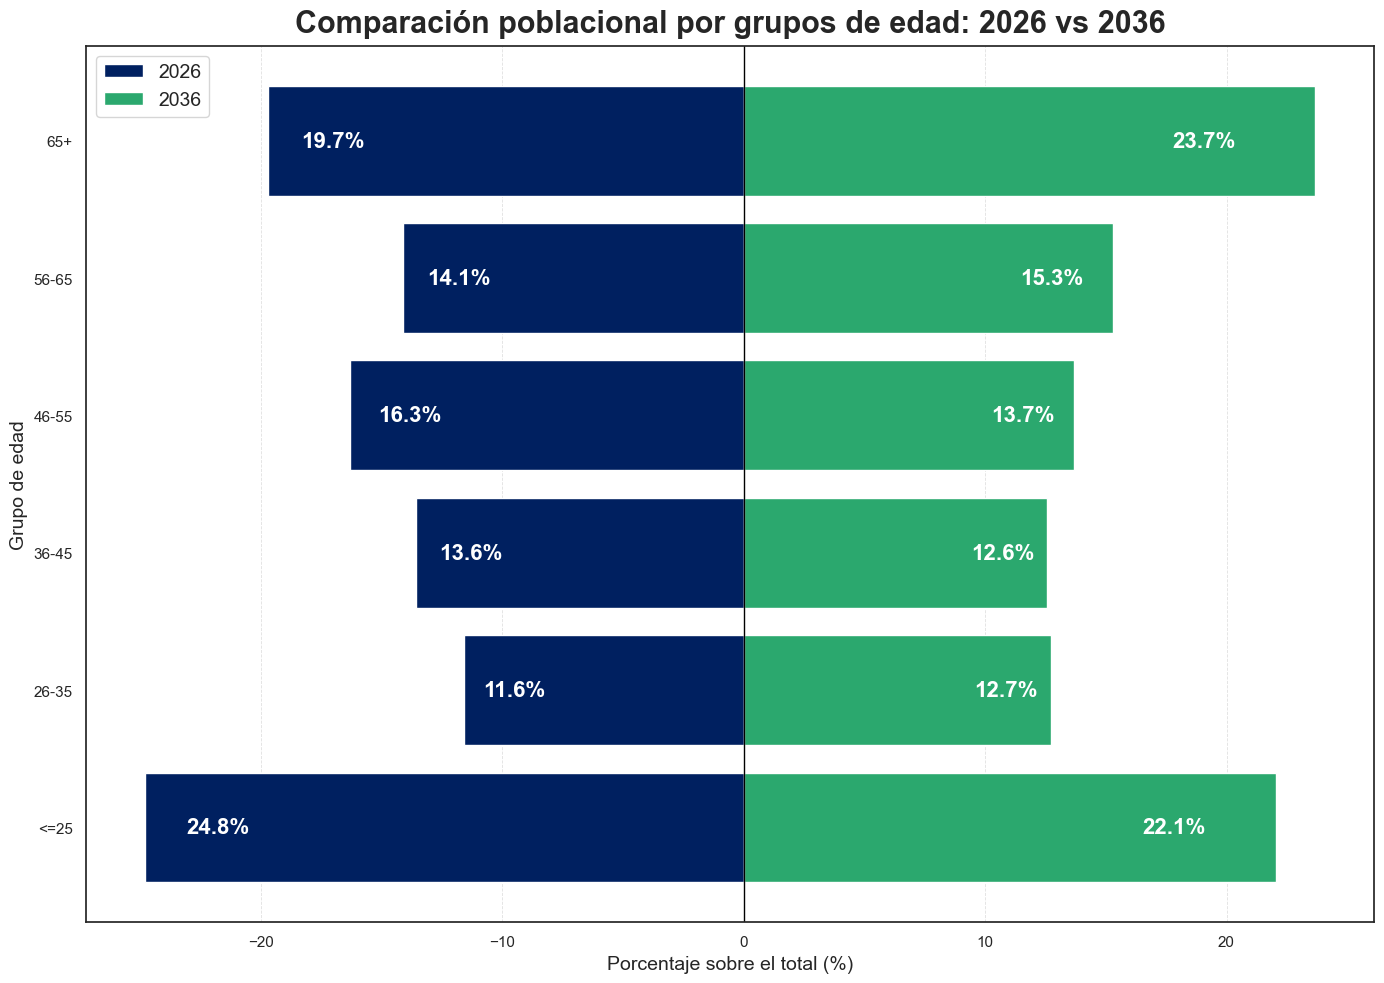

In [18]:
#Gráfico piramide 2026 vs 2036
# 1. Datos

cols_edad = ["<=25", "26-35", "36-45", "46-55", "56-65", "65+"]

df_pyr = proyeccion[proyeccion["Periodo"].isin([2026, 2036])].copy()

# Calcular porcentajes
for col in cols_edad:
    df_pyr[col] = df_pyr[col] / df_pyr["Total_pobl"] * 100

# Extraer series
datos_2026 = df_pyr[df_pyr["Periodo"] == 2026][cols_edad].iloc[0].values
datos_2036 = df_pyr[df_pyr["Periodo"] == 2036][cols_edad].iloc[0].values

# Para tornado: 2026 negativo
datos_2026_neg = -datos_2026

ages = cols_edad

# 2. Gráfico tornado

sns.set_theme(style="white")

plt.figure(figsize=(14, 10))

color_2026 = "#002060"
color_2036 = "#2BA86E"

# Barras
plt.barh(ages, datos_2026_neg, color=color_2026, label="2026")
plt.barh(ages, datos_2036, color=color_2036, label="2036")


# 3. Etiquetas dentro de las barras

# 2026 (lado izquierdo)
for y, v in enumerate(datos_2026_neg):
    plt.text(
        v * 0.93, y, f"{abs(v):.1f}%",
        va="center", ha="left",
        fontsize=16, color="white", fontweight="bold"
    )

# 2036 (lado derecho)
for y, v in enumerate(datos_2036):
    plt.text(
        v *0.75, y, f"{v:.1f}%",
        va="center", ha="left",
        fontsize=16, color="white", fontweight="bold"
    )


# 4. Estética

plt.axvline(0, color="black", linewidth=1)
plt.title("Comparación poblacional por grupos de edad: 2026 vs 2036",
          fontsize=22, fontweight="bold", pad = 10)

plt.xlabel("Porcentaje sobre el total (%)", fontsize=14)
plt.ylabel("Grupo de edad", fontsize=14)

plt.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.6)
plt.legend(fontsize=14)

plt.tight_layout()
plt.show()

In [12]:
# Incremento por edades:
anos_edad = proyeccion[proyeccion["Periodo"].isin([2026, 2036])][["Periodo","<=25", "26-35", "36-45", "46-55", "56-65", "65+"]].copy()

anos_edad = anos_edad.set_index("Periodo")
incremento = anos_edad.T.reset_index()
incremento["variacion"]= (incremento[2036] - incremento[2026]) / incremento[2026] * 100

incremento.sort_values(by="variacion", ascending=False, inplace=True)
incremento

Periodo,index,2026,2036,variacion
5,65+,"9,827,273.29","12,619,285.22",28.41
1,26-35,"5,779,888.16","6,776,514.31",17.24
4,56-65,"7,034,527.69","8,149,894.29",15.86
2,36-45,"6,768,906.31","6,688,302.37",-1.19
0,<=25,"12,376,813.34","11,749,486.45",-5.07
3,46-55,"8,122,847.57","7,297,655.90",-10.16


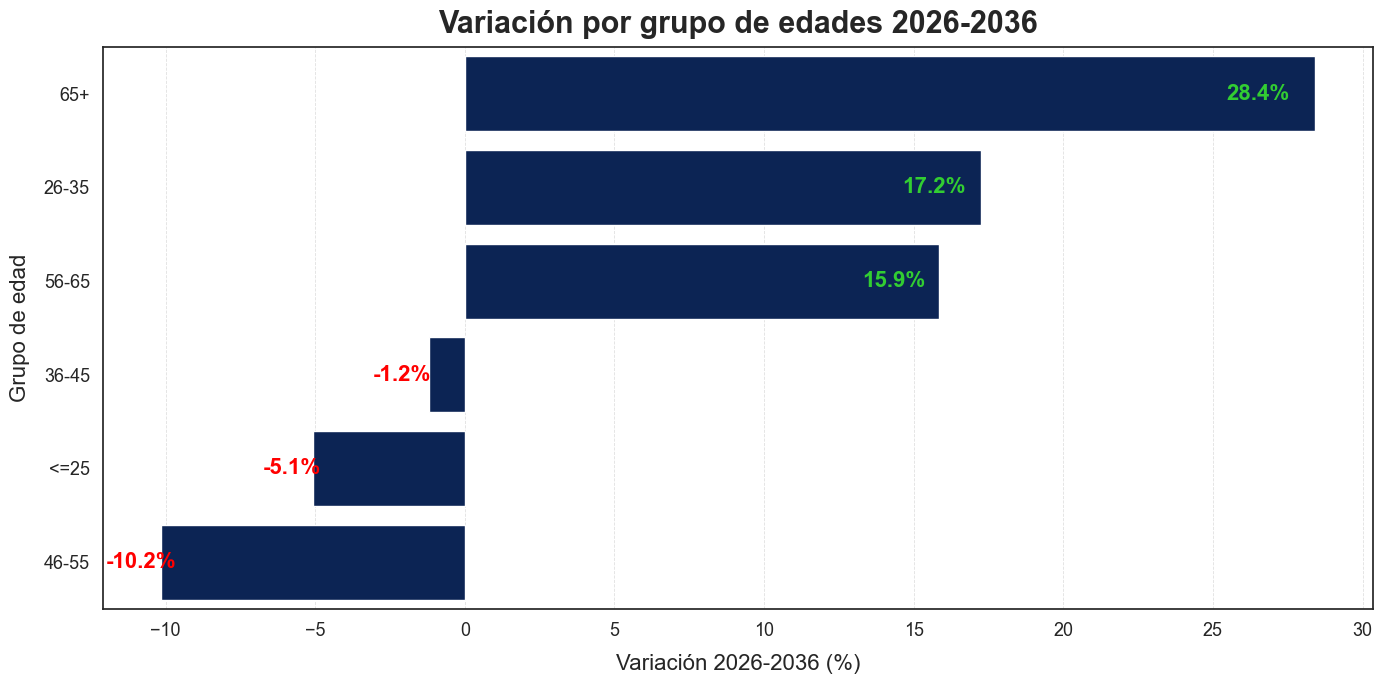

In [25]:
#Gráfico incrementos por edades:
plt.figure(figsize=(14, 7))

# Color corporativo:
#color=["#002060", "#2BA86E"]

sns.barplot(
    data=incremento,
    x="variacion",
    y="index",
    color="#002060",
    orient = "h"
)

plt.title(
    "Variación por grupo de edades 2026-2036",
    fontsize=22,
    fontweight="bold", pad = 10
)

plt.xlabel("Variación 2026-2036 (%)", fontsize=16, labelpad=10)
plt.ylabel("Grupo de edad", fontsize=16, labelpad=10)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.6)


for y, v in enumerate(incremento["variacion"]):
    if v >= 0:
        # Positivos → texto un poco a la izquierda del extremo
        plt.text(
            v - abs(v)*0.03,
            y,
            f"{v:.1f}%",
            va="center",
            ha="right",
            fontsize=16,
            color="limegreen",
            fontweight="bold"
        )
    else:
        # Negativos → texto un poco a la derecha del extremo
        plt.text(
            v + abs(v)*0.05,
            y,
            f"{v:.1f}%",
            va="center",
            ha="right",
            fontsize=16,
            color="red",
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

In [14]:
#Comparativa con distribución clientes empresa por edad:
anos_edad = proyeccion[proyeccion["Periodo"].isin([2026, 2036])][["Periodo","<=25", "26-35", "36-45", "46-55", "56-65", "65+"]].copy()
anos_edad = anos_edad.set_index("Periodo")
comparativa = anos_edad.T.reset_index()

comparativa



Periodo,index,2026,2036
0,<=25,"12,376,813.34","11,749,486.45"
1,26-35,"5,779,888.16","6,776,514.31"
2,36-45,"6,768,906.31","6,688,302.37"
3,46-55,"8,122,847.57","7,297,655.90"
4,56-65,"7,034,527.69","8,149,894.29"
5,65+,"9,827,273.29","12,619,285.22"


In [15]:
#distribucion empresa
df_age = dist_edad_banco.reset_index()
df_age.columns = ["index", "Clientes_empresa"]
df_age

,index,Clientes_empresa
0,<=25,449
1,26-35,3920
2,36-45,3162
3,46-55,2147
4,56-65,1086
5,65+,398


In [16]:
#unir datos por edades:
df_edades = comparativa.merge(df_age, on="index", how="left")

cols = [2026, 2036, "Clientes_empresa"]

df_edades[cols] = df_edades[cols].apply(lambda x: x / x.sum() * 100)

df_edades

,index,2026,2036,Clientes_empresa
0,<=25,24.80,22.05,4.02
1,26-35,11.58,12.72,35.12
2,36-45,13.56,12.55,28.33
3,46-55,16.27,13.70,19.23
4,56-65,14.09,15.30,9.73
5,65+,19.69,23.68,3.57


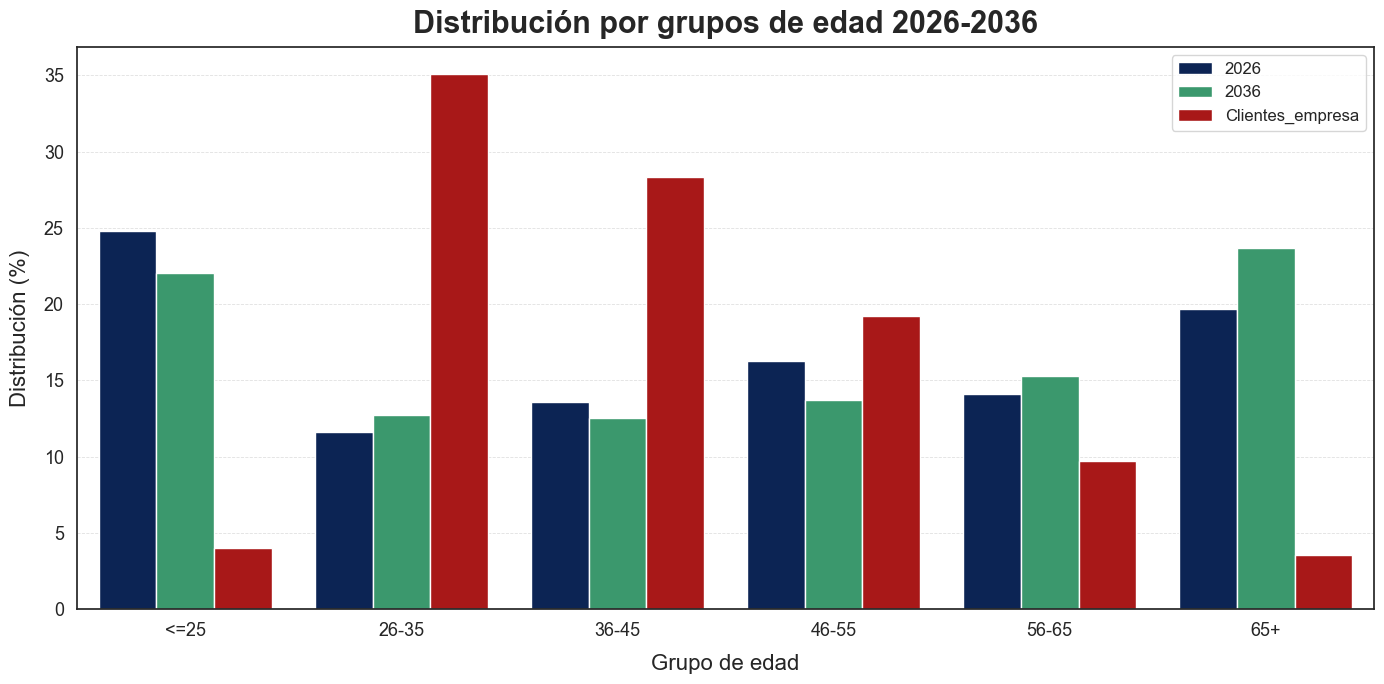

In [17]:
#Gráfico comparativa clientes por edades:
df_long = df_edades.melt(
    id_vars="index",
    value_vars=[2026, 2036, "Clientes_empresa"],
    var_name="tipo",
    value_name="porcentaje"
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=df_long,
    x="index",
    y="porcentaje",
    hue="tipo",
    palette=["#002060", "#2BA86E", "#C00000"]  # colores para 2026, 2036, clientes
)

plt.title(
    "Distribución por grupos de edad 2026-2036",
    fontsize=22,
    fontweight="bold",
    pad=10
)

plt.xlabel("Grupo de edad", fontsize=16, labelpad=10)
plt.ylabel("Distribución (%)", fontsize=16, labelpad=10)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

leg = plt.legend(title=None, fontsize=12, title_fontsize=13)

plt.tight_layout()
plt.show()